In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,seaborn"))
mpl.rcParams['pdf.fonttype'] = 42


Last updated: 2026-08-12T11:08:42.797936-07:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.6.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.7
seaborn   : 0.13.2



# Get Simulation Results

In [3]:
res = pd.read_csv('sum_stats_wtruth_revision.csv')

In [4]:
res["perfect"] = (res["fp"] == 0)

In [5]:
res

,gene_encoding_barcodes,eff_truth,fdr_truth,fp,not_decoded_true,total_true_cnts,nbarcodes,rep,code,ncodewords,perfect
0,0,0.0,0.000000,0,1,1,1,0,seqFISH_q12_n5_k4,20736,True
1,1,0.0,1.000000,1,1,1,1,1,seqFISH_q12_n5_k4,20736,False
2,1,1.0,0.000000,0,0,1,1,2,seqFISH_q12_n5_k4,20736,True
3,1,1.0,0.000000,0,0,1,1,3,seqFISH_q12_n5_k4,20736,True
4,1,1.0,0.000000,0,0,1,1,4,seqFISH_q12_n5_k4,20736,True
...,...,...,...,...,...,...,...,...,...,...,...
104995,9,0.1,0.888889,8,9,10,10,495,RS_q8n9k7w5_10421cws_greedy,10421,False
104996,9,0.2,0.777778,7,8,10,10,496,RS_q8n9k7w5_10421cws_greedy,10421,False
104997,8,0.1,0.875000,7,9,10,10,497,RS_q8n9k7w5_10421cws_greedy,10421,False
104998,9,0.2,0.777778,7,8,10,10,498,RS_q8n9k7w5_10421cws_greedy,10421,False


# Get Codebooks and their statistics

In [6]:
codebooks = {code:pd.read_csv("codebooks/" + code + "cb.csv") for code in np.unique(res.code)}

ncws_dict = {code:len(codebooks[code]) for code in np.unique(res.code) }
nimgs_dict = {}
for code in np.unique(res.code):
    if code[:7] == "seqFISH":
        nimgs_dict[code] = np.shape(codebooks[code].iloc[:,1:])[1]*(len(np.unique(codebooks[code].iloc[:,1:])))
    else:
        nimgs_dict[code] = np.shape(codebooks[code].iloc[:,1:])[1]*(len(np.unique(codebooks[code].iloc[:,1:]))-1)

#The following codes had pseudocolors removed from select barcoding blocks to match the number of images used in experiments previously reported in the literature

nimgs_dict['RS_q9n9k8w4cb_12903cws_greedy'] = 69
nimgs_dict['RS_q8n9k7w5_10421cws_greedy'] = 60


In [7]:
codebook_weights = {}
for code in codebooks.keys():
    if code == 'RS_q8_n9_k6_w5':
        codebook_weights[code] = 5
    elif code[:7] != "seqFISH":
        codebook_weights[code] = (codebooks[code].iloc[:, 1:] != 0).sum(axis=1)[0]
    elif code in ['seqFISHDNA_2020', 'seqFISH_intron_2018', 'seqFISH_q12_n5_k4', 'seqFISH_q16_n5_k3']:
        codebook_weights[code] = 5
    else:
        codebook_weights[code] = 4

#Revision codes
codebook_weights['RS_q9n9k8w4cb_12903cws_greedy'] = 4
codebook_weights['RS_q8n9k7w5_10421cws_greedy'] = 5
codebook_weights['RS_q9n10k8w4cb_3334cws_16hr'] = 4
codebook_weights['RS_q9n10k6w5cb_1267cws_16hr'] = 5

 # Make better names for some columns

In [8]:
res.loc[res.code == "RS_q9n9k8w4cb_12903cws_greedy", "code"] = 'q9n9k8w4cb'
ncws_dict["q9n9k8w4cb"] = ncws_dict["RS_q9n9k8w4cb_12903cws_greedy"]
nimgs_dict["q9n9k8w4cb"] = nimgs_dict["RS_q9n9k8w4cb_12903cws_greedy"]
codebook_weights["q9n9k8w4cb"] = codebook_weights["RS_q9n9k8w4cb_12903cws_greedy"]

res.loc[res.code == "RS_q9n10k8w4cb_3334cws_16hr", "code"] = 'q9n10k8w4'
ncws_dict["q9n10k8w4"] = ncws_dict["RS_q9n10k8w4cb_3334cws_16hr"]
nimgs_dict["q9n10k8w4"] = nimgs_dict["RS_q9n10k8w4cb_3334cws_16hr"]
codebook_weights["q9n10k8w4"] = codebook_weights["RS_q9n10k8w4cb_3334cws_16hr"]

res.loc[res.code == "RS_q9n10k6w5cb_1267cws_16hr", "code"] = 'q9n10k6w5'
ncws_dict["q9n10k6w5"] = ncws_dict["RS_q9n10k6w5cb_1267cws_16hr"]
nimgs_dict["q9n10k6w5"] = nimgs_dict["RS_q9n10k6w5cb_1267cws_16hr"]
codebook_weights["q9n10k6w5"] = codebook_weights["RS_q9n10k6w5cb_1267cws_16hr"]

res.loc[res.code == "RS_q8n9k7w5_10421cws_greedy", "code"] = 'q8n9k7w5'
ncws_dict["q8n9k7w5"] = ncws_dict["RS_q8n9k7w5_10421cws_greedy"]
nimgs_dict["q8n9k7w5"] = nimgs_dict["RS_q8n9k7w5_10421cws_greedy"]
codebook_weights["q8n9k7w5"] = codebook_weights["RS_q8n9k7w5_10421cws_greedy"]


res.loc[res.code == "Hamming_q2_n16_k11_w4cb_MERFISH_2015", "code"] = "MERFISH_2015"
ncws_dict["MERFISH_2015"] = ncws_dict["Hamming_q2_n16_k11_w4cb_MERFISH_2015"]
nimgs_dict["MERFISH_2015"] = nimgs_dict["Hamming_q2_n16_k11_w4cb_MERFISH_2015"]
codebook_weights["MERFISH_2015"] = codebook_weights["Hamming_q2_n16_k11_w4cb_MERFISH_2015"]

res.loc[res.code == "seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1", "code"] = "q25_n4_k3"
ncws_dict["q25_n4_k3"] = ncws_dict["seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1"]
nimgs_dict["q25_n4_k3"] = nimgs_dict["seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1"]
codebook_weights["q25_n4_k3"] = codebook_weights["seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1"]

res.loc[res.code == "seqFISH_n4k3q25_parity_check", "code"] = "full_q25_n4_k3"
ncws_dict["full_q25_n4_k3"] = ncws_dict["seqFISH_n4k3q25_parity_check"]
nimgs_dict["full_q25_n4_k3"] = nimgs_dict["seqFISH_n4k3q25_parity_check"]
codebook_weights["full_q25_n4_k3"] = codebook_weights["seqFISH_n4k3q25_parity_check"]

res.loc[res.code == "unstructured_100bit_w5_md6", "code"] = "NL_w5_md6"
ncws_dict["NL_w5_md6"] = ncws_dict["unstructured_100bit_w5_md6"]
nimgs_dict["NL_w5_md6"] = nimgs_dict["unstructured_100bit_w5_md6"]
codebook_weights["NL_w5_md6"] = codebook_weights["unstructured_100bit_w5_md6"]

res.loc[res.code == "q11_n10_k7_w4cb_pool1", "code"] = "q11n10k7w4"
ncws_dict["q11n10k7w4"] = ncws_dict["q11_n10_k7_w4cb_pool1"]
nimgs_dict["q11n10k7w4"] = nimgs_dict["q11_n10_k7_w4cb_pool1"]
codebook_weights["q11n10k7w4"] = codebook_weights["q11_n10_k7_w4cb_pool1"]


In [9]:
res["Number of Barcodes"] = res["nbarcodes"]
reps_summed = res.groupby(['code','ncodewords', 'Number of Barcodes']).sum()
reps_summed['correct_barcodes'] = reps_summed['gene_encoding_barcodes'] - reps_summed['fp']
reps_summed["Efficiency"] = reps_summed['correct_barcodes']/reps_summed['total_true_cnts']
reps_summed["False Discovery Rate"] = reps_summed['fp']/reps_summed['gene_encoding_barcodes']
reps_summed.reset_index(inplace=True)
reps_summed["ylabel"] = [code + "_ncws" + str(ncws_dict[code]) + "_nimgs" + str(nimgs_dict[code]) for code in reps_summed.code]
reps_summed["prop_perfect"] = reps_summed["perfect"]/500

 # Make Table of plot data

In [10]:
fdr_table = reps_summed.set_index("Number of Barcodes")
fdr_table.reset_index(inplace=True)
fdr_table = fdr_table.set_index(["code", "Number of Barcodes"]) #, "Number of Codewords"])
fdr_table = fdr_table.loc[:,["False Discovery Rate", "Efficiency"]]
fdr_table = fdr_table.unstack("Number of Barcodes")


In [11]:
fdr_table

False Discovery Rate                                \
Number of Barcodes                       1         2         3         4    
code                                                                        
MERFISH_2015                       0.006042  0.139800  0.279746  0.395982   
MERFISH_2019                       0.069364  0.141834  0.276852  0.409243   
NL_w5_md6                          0.002710  0.002874  0.015697  0.043085   
RS_q11_n10_k7_w4                   0.005764  0.004451  0.021256  0.026130   
RS_q13_n10_k6_w6                   0.002786  0.002747  0.001803  0.005355   
RS_q13_n13_k9_w5                   0.000000  0.004076  0.001845  0.011034   
RS_q8_n9_k6_w5                     0.005391  0.012431  0.039747  0.070517   
full_q25_n4_k3                     0.040698  0.089779  0.188714  0.310884   
q11n10k7w4                         0.000000  0.000000  0.002913  0.004313   
q17n12md5w5                        0.000000  0.000000  0.003215  0.003953   
q25_n4_k3                          0.003049  0.002865  0.002924  0.005208   
q8n9k7w5                           0.005420  0.085992  0.176781  0.292165   
q9n10k6w5                          0.000000  0.001366  0.000900  0.007519   
q9n10k8w4                          0.005970  0.032353  0.068695  0.117689   
q9n9k8w4cb                         0.112360  0.231824  0.368186  0.514094   
seqFISHDNA_2020                    0.000000  0.002751  0.010850  0.021031   
seqFISH_intron_2018                0.011364  0.100559  0.222418  0.395532   
seqFISH_q12_n5_k4                  0.022284  0.204301  0.412985  0.556774   
seqFISH_q16_n5_k3                  0.005450  0.020661  0.062442  0.079248   
seqFISHp2019                       0.032934  0.098408  0.164662  0.293789   
seqFISHp2019_used_only             0.017857  0.039492  0.078261  0.127825   

                                                                          \
Number of Barcodes            5         6         7         8         9    
code                                                                       
MERFISH_2015            0.489253  0.564145  0.617637  0.635438  0.659375   
MERFISH_2019            0.541256  0.653943  0.715937  0.787373  0.829616   
NL_w5_md6               0.070252  0.133061  0.184394  0.266869  0.361696   
RS_q11_n10_k7_w4        0.042442  0.058034  0.094074  0.135077  0.159835   
RS_q13_n10_k6_w6        0.018252  0.037443  0.059029  0.102367  0.156840   
RS_q13_n13_k9_w5        0.016750  0.031192  0.035047  0.046599  0.080747   
RS_q8_n9_k6_w5          0.141689  0.232095  0.329421  0.408000  0.548278   
full_q25_n4_k3          0.389589  0.495821  0.566753  0.662739  0.695676   
q11n10k7w4              0.007549  0.006715  0.006939  0.013803  0.018095   
q17n12md5w5             0.008145  0.011417  0.020711  0.028449  0.042224   
q25_n4_k3               0.010216  0.004701  0.014350  0.023775  0.023878   
q8n9k7w5                0.427390  0.548293  0.675000  0.732836  0.798749   
q9n10k6w5               0.008542  0.018116  0.032667  0.052189  0.071343   
q9n10k8w4               0.182394  0.243357  0.302959  0.377371  0.435340   
q9n9k8w4cb              0.646429  0.702243  0.763112  0.802632  0.823131   
seqFISHDNA_2020         0.033388  0.058218  0.068525  0.103307  0.129613   
seqFISH_intron_2018     0.505300  0.675249  0.735025  0.786473  0.806528   
seqFISH_q12_n5_k4       0.692774  0.775510  0.826644  0.860541  0.892005   
seqFISH_q16_n5_k3       0.144935  0.198024  0.278457  0.326201  0.400636   
seqFISHp2019            0.388497  0.510394  0.621116  0.627656  0.716671   
seqFISHp2019_used_only  0.188464  0.294848  0.350670  0.428571  0.508638   

                                 Efficiency                                   \
Number of Barcodes            10         1      2         3       4       5    
code                                                                           
MERFISH_2015            0.685807      0.658  0.603  0.528667  0.4660  0.3992   
MERFISH_2019            0.850

In [12]:
code_mds = {
    'q8n9k7w5' : 3,
    'q9n10k6w5' : 5,
    'q9n10k8w4' : 3,
    'q9n9k8w4cb' : 2,
    'seqFISH_intron_2018' : 2,
    'seqFISHp2019_used_only': 2,
    'seqFISHDNA_2020' : 2,
    'MERFISH_2015' : 4,
    'RS_q13_n13_k9_w5' : 5,
    'RS_q13_n10_k6_w6' : 5,
    'RSq13n10md5w6' : 5,
    'q17n12md5w5' : 5,
    'q11n10k7w4' : 4,
    'RS_q8_n9_k6_w5' : 4,
    'RS_q8_n9_k6_w6': 4,
    'MERFISH_2019' : 4,
    'seqFISHp2019_repetition': 2
}

code_q = {
    'q8n9k7w5' : 8,
     'q9n10k6w5' : 9,
     'q9n10k8w4' : 9,
     'q9n9k8w4cb' : 9,
    'seqFISH_intron_2018' : 12,
    'seqFISHp2019_used_only' : 20,
    'seqFISHDNA_2020' : 16,
    'MERFISH_2015' : 2,
    'RS_q13_n13_k9_w5' : 13,
    'RS_q13_n10_k6_w6' : 13,
    'RSq13n10md5w6' : 13,
    'q17n12md5w5' : 17,
    '#RS_q11_n10_k7_w4' : 11,
    'q11n10k7w4' : 11,
    'RS_q8_n9_k6_w5' : 8,
    'RS_q8_n9_k6_w6': 8,
    'MERFISH_2019' : 2,
    'seqFISHp2019_repetition': 20
}

code_n = {
    'q8n9k7w5' : 9,
    'q9n10k6w5' : 10,
    'q9n10k8w4' : 10,
    'q9n9k8w4cb' : 9,
    'seqFISH_intron_2018' : 5,
    'seqFISHp2019_used_only' : 4,
    'seqFISHDNA_2020' : 5,
    'MERFISH_2015' : 16,
    'RS_q13_n13_k9_w5' : 13,
    'RS_q13_n10_k6_w6' : 10,
    'RSq13n10md5w6' : 10,
    'q17n12md5w5' : 12,
    'q11n10k7w4' : 10,
    'RS_q8_n9_k6_w5' : 9,
    'MERFISH_2019' : 69,
    'seqFISHp2019_repetition': 6
}

In [13]:
reps_summed = reps_summed.loc[reps_summed.ylabel != "RSq13n10md5w6_ncws10560_nimgs120"]

In [14]:
plot_order_dict = {
    'q8n9k7w5' : 5,
    'q9n10k6w5' : 6,
    'q9n10k8w4' : 7,
    'q9n9k8w4cb' : 8,
    'seqFISHp2019_used_only' : 3,
    'seqFISHDNA_2020' : 4,
    'MERFISH_2015' : 10,
    #'RS_q13_n13_k9_w5' : 4,
    #'RS_q13_n10_k6_w6' : 5,
    #'q17n12md5w5' : 6,
    'q11n10k7w4' : 0,
    'q17n12md5w5' : 1,
    #'RS_q8_n9_k6_w5' : 8,
    'MERFISH_2019' : 9,
    'seqFISH_intron_2018' : 2
}
    

In [15]:
plot_order_dict = {
    'q17n12md5w5' : 1,
    'q8n9k7w5' : 2,
    'q9n10k6w5' : 4,
    'q9n10k8w4' : 3,
    'q9n9k8w4cb' : 5,
    'seqFISHp2019_used_only' : 7,
    'seqFISHDNA_2020' : 8,
    'MERFISH_2015' : 10,
    #'RS_q13_n13_k9_w5' : 4,
    #'RS_q13_n10_k6_w6' : 5,
    #'q17n12md5w5' : 6,
    'q11n10k7w4' : 0, #5,
    #'RS_q8_n9_k6_w5' : 8,
    'MERFISH_2019' : 9,
    'seqFISH_intron_2018' : 6
}
    

i:  0 ; g[0]:  MERFISH_2015_ncws140_nimgs16
i:  1 ; g[0]:  MERFISH_2019_ncws12903_nimgs69
i:  2 ; g[0]:  NL_w5_md6_ncws12267_nimgs100
i:  3 ; g[0]:  RS_q11_n10_k7_w4_ncws2100_nimgs100
i:  4 ; g[0]:  RS_q13_n10_k6_w6_ncws20160_nimgs120
i:  5 ; g[0]:  RS_q13_n13_k9_w5_ncws15444_nimgs156
i:  6 ; g[0]:  RS_q8_n9_k6_w5_ncws3528_nimgs63
i:  7 ; g[0]:  full_q25_n4_k3_ncws15625_nimgs100
i:  8 ; g[0]:  q11n10k7w4_ncws271_nimgs100
i:  9 ; g[0]:  q17n12md5w5_ncws12672_nimgs192
i:  10 ; g[0]:  q25_n4_k3_ncws271_nimgs100
i:  11 ; g[0]:  q8n9k7w5_ncws10421_nimgs60
i:  12 ; g[0]:  q9n10k6w5_ncws1267_nimgs80
i:  13 ; g[0]:  q9n10k8w4_ncws3334_nimgs80
i:  14 ; g[0]:  q9n9k8w4cb_ncws12903_nimgs69
i:  15 ; g[0]:  seqFISHDNA_2020_ncws1267_nimgs80
i:  16 ; g[0]:  seqFISH_intron_2018_ncws10421_nimgs60
i:  17 ; g[0]:  seqFISH_q12_n5_k4_ncws20736_nimgs60
i:  18 ; g[0]:  seqFISH_q16_n5_k3_ncws4096_nimgs80
i:  19 ; g[0]:  seqFISHp2019_ncws8000_nimgs80
i:  20 ; g[0]:  seqFISHp2019_used_only_ncws3334_nimgs80


C:\Users\jonat\AppData\Local\Temp\ipykernel_9140\1989843010.py:79: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lnd_artist = plt.legend(loc='upper right', bbox_to_anchor=(1.85,10))


code:  seqFISHp2019_used_only


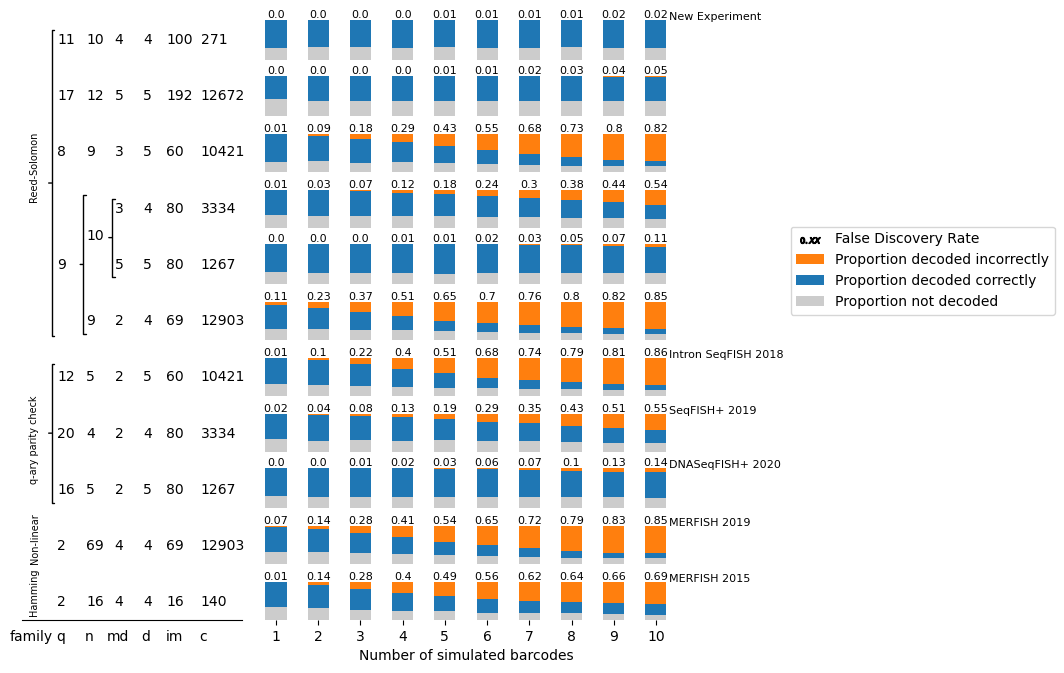

In [ ]:
fig = plt.figure(figsize=(7,6.0))
ax = fig.subplot_mosaic(
    [
        ["label_tree", "q11n10k7w4"],
        ["label_tree", "q17n12md5w5"],
        ["label_tree", "q8n9k7w5"],
        ["label_tree", 'q9n10k8w4'],
        ["label_tree", "q9n10k6w5"],
        ["label_tree", "q9n9k8w4cb"],
        ["label_tree", "seqFISH_intron_2018"],
        ["label_tree", "seqFISHp2019_used_only"],
        ["label_tree", "seqFISHDNA_2020"],
        ["label_tree", "MERFISH_2019"],
        ["label_tree", "MERFISH_2015"],
    ],
    width_ratios=[1, 2],
)
ax["label_tree"].spines.top.set_visible(False)
ax["label_tree"].spines.right.set_visible(False)
ax["label_tree"].spines.left.set_visible(False)
ax["label_tree"].spines.bottom.set_visible(False)
ax["label_tree"].tick_params(bottom=False, left=False, labelleft=False)


ax["label_tree"].plot(["family", "q", "n", "md", "d", "im", "c", ""], [1,1,1,1,1,1,1,1], markersize=0,c="w")
ax["label_tree"].set_ylim(0,1)

tree_height_factor = 9.7 * 11/10

txt_top = 0.96
bar_width = 0.5


for i, grp in enumerate(reps_summed.groupby("ylabel")):
    print("i: ", i, "; g[0]: ", grp[0])
    code = grp[1].code.iloc[0]

    bottom = np.zeros(len(grp[1]))

    eff = grp[1]["Efficiency"]
    false = grp[1]["fp"]/grp[1]['nbarcodes']
    mis = 1 - eff - false
    fdr = grp[1]["False Discovery Rate"]

    if code in ax:
        #ax[code].scatter([1],[0.3], s=200,marker = '$0.XX$', color='k', label="False Discovery Rate")
        p = ax[code].bar(grp[1]['Number of Barcodes'], false, bar_width, label="Proportion decoded incorrectly", bottom=1-false, color= "tab:orange")
        ax[code].bar_label(p, np.round(fdr,2),size=8, label="False Discovery Rate")
                          
        p = ax[code].bar(grp[1]['Number of Barcodes'], eff, bar_width, label="Proportion decoded correctly", bottom=mis, color="tab:blue")
        p = ax[code].bar(grp[1]['Number of Barcodes'], mis, bar_width, label="Proportion not decoded", bottom=bottom, color="#cccccc")
    
    
        
        ncws = grp[1].ncodewords.iloc[0]
        
        ax[code].spines.top.set_visible(False)
        ax[code].spines.right.set_visible(False)
        ax[code].spines.left.set_visible(False)
        ax[code].spines.bottom.set_visible(False)
        ax[code].tick_params(bottom=False, left=False, labelleft=False, labelbottom=False)

        #if code in code_n and code_n[code] != 6:
        if code_q[code] != 9 or code == 'q9n10k6w5':
            #if code_q[code] != 13:
            ax["label_tree"].text(0.9,txt_top-plot_order_dict[code]/tree_height_factor,code_q[code])
            #if code_n[code] == 9:
            if not(code_n[code] == 10 and code_q[code] == 9):
                ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code])
        if code == 'q9n9k8w4cb':
            ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code])
        ax["label_tree"].text(2.9,txt_top-plot_order_dict[code]/tree_height_factor,code_mds[code])
        ax["label_tree"].text(3.9,txt_top-plot_order_dict[code]/tree_height_factor,codebook_weights[code])
        ax["label_tree"].text(4.7,txt_top-plot_order_dict[code]/tree_height_factor,nimgs_dict[code])
        ax["label_tree"].text(5.9,txt_top-plot_order_dict[code]/tree_height_factor,ncws_dict[code])

ax["label_tree"].spines.bottom.set_visible(True)

lnd_artist = plt.legend(loc='upper right', bbox_to_anchor=(1.85,10))

print("code: ", code)

offset = 0.046
bracket_offset = 0.039 + 0.003



#ax["label_tree"].text(0.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_q["q9n10k8w4"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_n["q9n10k8w4"])
ax["label_tree"].annotate("",
                          (2.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor - bracket_offset), #(1.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor - bracket_offset),
                          (2.6,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor - bracket_offset), #(1.6,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.8, lengthB=0.2,angleB=0"}
                         )

ax['seqFISH_intron_2018'].text(10.3,1,"Intron SeqFISH 2018",size=8)
ax['seqFISHp2019_used_only'].text(10.3,1,"SeqFISH+ 2019",size=8)
ax['seqFISHDNA_2020'].text(10.3,1,"DNASeqFISH+ 2020",size=8)
ax['MERFISH_2015'].text(10.3,1,"MERFISH 2015",size=8)
ax['q11n10k7w4'].text(10.3,1,"New Experiment",size=8)
ax['MERFISH_2019'].text(10.3,1,"MERFISH 2019",size=8)


ax['MERFISH_2015'].set_xticks([1,2,3,4,5,6,7,8,9,10])
ax['MERFISH_2015'].set_xlabel("Number of simulated barcodes")
ax['MERFISH_2015'].tick_params(bottom=True, labelbottom=True)


brackets = []
pc_bracket = FancyArrowPatch((0.0,0.8),(0.2,0.8), arrowstyle={'arrowstyle':"-[,widthB=0.0, lengthB=0.2, angleB=0"}, mutation_scale=42)

fig.text(0.06,txt_top-plot_order_dict["seqFISHDNA_2020"]/tree_height_factor+0.02,"q-ary parity check",rotation="vertical",fontsize=7)
ax["label_tree"].annotate("",
                          (0.8,txt_top-plot_order_dict["seqFISHp2019_used_only"]/tree_height_factor + 0.007), #-bracket_offset),
                          (0.5,txt_top-plot_order_dict["seqFISHp2019_used_only"]/tree_height_factor + 0.007), #-bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=5, lengthB=0.2,angleB=0"}
                         )

fig.text(0.06,0.01,"Hamming",rotation="vertical",fontsize=7)

RS_bracket = FancyArrowPatch((45,265),(55,265), arrowstyle="-[,widthB=2.1, lengthB=0.2, angleB=0", mutation_scale=42)
brackets.append(RS_bracket)
fig.text(0.06,0.7,"Reed-Solomon",rotation="vertical",fontsize=7)
ax["label_tree"].annotate("",
                          (0.8,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor + bracket_offset + 0.007), #+ 0.007),
                          (0.5,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor + bracket_offset + 0.007), #+ 0.007),
                          arrowprops={'arrowstyle':"-[,widthB=11, lengthB=0.2,angleB=0"}
                         )

#fig.text(0.06,0.6,"Reed-Solomon",rotation="vertical",fontsize=7)
ax["label_tree"].annotate("",
                          (1.9,txt_top-plot_order_dict["q9n10k6w5"]/tree_height_factor + 0.007),
                          (1.6,txt_top-plot_order_dict["q9n10k6w5"]/tree_height_factor + 0.007),
                          arrowprops={'arrowstyle':"-[,widthB=5, lengthB=0.2,angleB=0"}
                         )


ax["label_tree"].text(-0.04,txt_top-plot_order_dict["MERFISH_2019"]/tree_height_factor - 0.02,"Non-linear",rotation="vertical",fontsize=7)

plt.subplots_adjust(left=0.05,
                    bottom=0.0, 
                    right=1.0, 
                    top=1, 
                    wspace=0.01, 
                    hspace=0.4)

plt.savefig('fig2A_revised3.pdf', bbox_inches = 'tight') #, pad_inches = 5) # bbox_extra_artists=[lnd_artist])

In [17]:
plot_order_dict = {
    'q8n9k7w5' : 0,
    'q9n10k6w5' : 2,
    'q9n10k8w4' : 1,
    'q9n9k8w4cb' : 3,
    'seqFISHp2019_used_only' : 5,
    'seqFISHDNA_2020' : 6,
    'MERFISH_2015' : 8,
    'MERFISH_2019' : 7,
    'seqFISH_intron_2018' : 4
}
    

i:  0 ; g[0]:  MERFISH_2015_ncws140_nimgs16
i:  1 ; g[0]:  MERFISH_2019_ncws12903_nimgs69
i:  2 ; g[0]:  NL_w5_md6_ncws12267_nimgs100
i:  3 ; g[0]:  RS_q11_n10_k7_w4_ncws2100_nimgs100
i:  4 ; g[0]:  RS_q13_n10_k6_w6_ncws20160_nimgs120
i:  5 ; g[0]:  RS_q13_n13_k9_w5_ncws15444_nimgs156
i:  6 ; g[0]:  RS_q8_n9_k6_w5_ncws3528_nimgs63
i:  7 ; g[0]:  full_q25_n4_k3_ncws15625_nimgs100
i:  8 ; g[0]:  q11n10k7w4_ncws271_nimgs100
i:  9 ; g[0]:  q17n12md5w5_ncws12672_nimgs192
i:  10 ; g[0]:  q25_n4_k3_ncws271_nimgs100
i:  11 ; g[0]:  q8n9k7w5_ncws10421_nimgs60
i:  12 ; g[0]:  q9n10k6w5_ncws1267_nimgs80
i:  13 ; g[0]:  q9n10k8w4_ncws3334_nimgs80
i:  14 ; g[0]:  q9n9k8w4cb_ncws12903_nimgs69
i:  15 ; g[0]:  seqFISHDNA_2020_ncws1267_nimgs80
i:  16 ; g[0]:  seqFISH_intron_2018_ncws10421_nimgs60
i:  17 ; g[0]:  seqFISH_q12_n5_k4_ncws20736_nimgs60
i:  18 ; g[0]:  seqFISH_q16_n5_k3_ncws4096_nimgs80
i:  19 ; g[0]:  seqFISHp2019_ncws8000_nimgs80
i:  20 ; g[0]:  seqFISHp2019_used_only_ncws3334_nimgs80
code

C:\Users\jonat\AppData\Local\Temp\ipykernel_9140\1362438004.py:79: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lnd_artist = plt.legend(loc='upper right', bbox_to_anchor=(1.85,10))


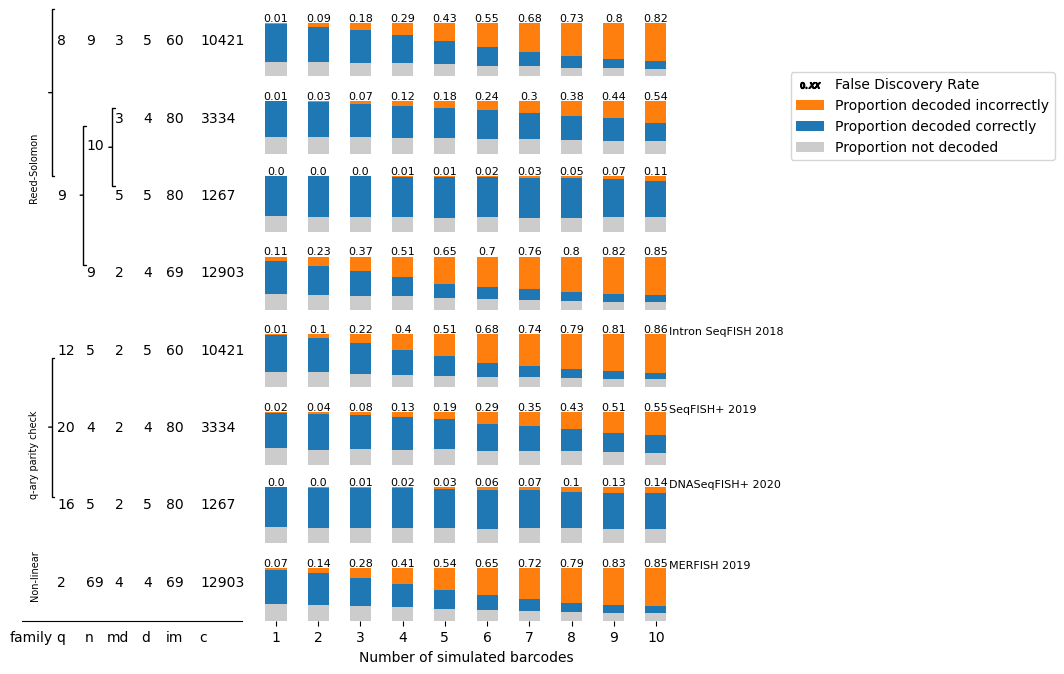

In [ ]:
fig = plt.figure(figsize=(7,6.0))
ax = fig.subplot_mosaic(
    [
        #["label_tree", "q11n10k7w4"],
        #["label_tree", "q17n12md5w5"],
        ["label_tree", "q8n9k7w5"],
        ["label_tree", 'q9n10k8w4'],
        ["label_tree", "q9n10k6w5"],
        ["label_tree", "q9n9k8w4cb"],
        ["label_tree", "seqFISH_intron_2018"],
        ["label_tree", "seqFISHp2019_used_only"],
        ["label_tree", "seqFISHDNA_2020"],
        ["label_tree", "MERFISH_2019"],
        #["label_tree", "MERFISH_2015"],
    ],
    width_ratios=[1, 2],
)
ax["label_tree"].spines.top.set_visible(False)
ax["label_tree"].spines.right.set_visible(False)
ax["label_tree"].spines.left.set_visible(False)
ax["label_tree"].spines.bottom.set_visible(False)
ax["label_tree"].tick_params(bottom=False, left=False, labelleft=False)


ax["label_tree"].plot(["family", "q", "n", "md", "d", "im", "c", ""], [1,1,1,1,1,1,1,1], markersize=0,c="w")
ax["label_tree"].set_ylim(0,1)

tree_height_factor = 9.7 * 8/10

txt_top = 0.96
bar_width = 0.5


for i, grp in enumerate(reps_summed.groupby("ylabel")):
    print("i: ", i, "; g[0]: ", grp[0])
    code = grp[1].code.iloc[0]

    bottom = np.zeros(len(grp[1]))

    eff = grp[1]["Efficiency"]
    false = grp[1]["fp"]/grp[1]['nbarcodes']
    mis = 1 - eff - false
    fdr = grp[1]["False Discovery Rate"]

    if code in ax:
        #ax[code].scatter([1],[0.3], s=200,marker = '$0.XX$', color='k', label="False Discovery Rate")
        p = ax[code].bar(grp[1]['Number of Barcodes'], false, bar_width, label="Proportion decoded incorrectly", bottom=1-false, color= "tab:orange")
        ax[code].bar_label(p, np.round(fdr,2),size=8, label="False Discovery Rate")
                          
        p = ax[code].bar(grp[1]['Number of Barcodes'], eff, bar_width, label="Proportion decoded correctly", bottom=mis, color="tab:blue")
        p = ax[code].bar(grp[1]['Number of Barcodes'], mis, bar_width, label="Proportion not decoded", bottom=bottom, color="#cccccc")
    
    
        
        ncws = grp[1].ncodewords.iloc[0]
        
        ax[code].spines.top.set_visible(False)
        ax[code].spines.right.set_visible(False)
        ax[code].spines.left.set_visible(False)
        ax[code].spines.bottom.set_visible(False)
        ax[code].tick_params(bottom=False, left=False, labelleft=False, labelbottom=False)

        #if code in code_n and code_n[code] != 6:
        if code_q[code] != 9 or code == 'q9n10k6w5':
            #if code_q[code] != 13:
            ax["label_tree"].text(0.9,txt_top-plot_order_dict[code]/tree_height_factor,code_q[code])
            #if code_n[code] == 9:
            if not(code_n[code] == 10 and code_q[code] == 9):
                ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code])
        if code == 'q9n9k8w4cb':
            ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code])
        ax["label_tree"].text(2.9,txt_top-plot_order_dict[code]/tree_height_factor,code_mds[code])
        ax["label_tree"].text(3.9,txt_top-plot_order_dict[code]/tree_height_factor,codebook_weights[code])
        ax["label_tree"].text(4.7,txt_top-plot_order_dict[code]/tree_height_factor,nimgs_dict[code])
        ax["label_tree"].text(5.9,txt_top-plot_order_dict[code]/tree_height_factor,ncws_dict[code])

ax["label_tree"].spines.bottom.set_visible(True)

lnd_artist = plt.legend(loc='upper right', bbox_to_anchor=(1.85,10))

print("code: ", code)

offset = 0.046
bracket_offset = 0.039 + 0.003



#ax["label_tree"].text(0.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_q["q9n10k8w4"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_n["q9n10k8w4"])
ax["label_tree"].annotate("",
                          (2.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor - bracket_offset), #(1.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor - bracket_offset),
                          (2.6,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor - bracket_offset), #(1.6,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.8, lengthB=0.2,angleB=0"}
                         )

ax['seqFISH_intron_2018'].text(10.3,1,"Intron SeqFISH 2018",size=8)
ax['seqFISHp2019_used_only'].text(10.3,1,"SeqFISH+ 2019",size=8)
ax['seqFISHDNA_2020'].text(10.3,1,"DNASeqFISH+ 2020",size=8)
ax['MERFISH_2019'].text(10.3,1,"MERFISH 2019",size=8)


ax['MERFISH_2019'].set_xticks([1,2,3,4,5,6,7,8,9,10])
ax['MERFISH_2019'].set_xlabel("Number of simulated barcodes")
ax['MERFISH_2019'].tick_params(bottom=True, labelbottom=True)


brackets = []
pc_bracket = FancyArrowPatch((0.0,0.8),(0.2,0.8), arrowstyle={'arrowstyle':"-[,widthB=0.0, lengthB=0.2, angleB=0"}, mutation_scale=42)

fig.text(0.06,txt_top-plot_order_dict["seqFISHDNA_2020"]/tree_height_factor+0.02,"q-ary parity check",rotation="vertical",fontsize=7)
ax["label_tree"].annotate("",
                          (0.8,txt_top-plot_order_dict["seqFISHp2019_used_only"]/tree_height_factor + 0.007), #-bracket_offset),
                          (0.5,txt_top-plot_order_dict["seqFISHp2019_used_only"]/tree_height_factor + 0.007), #-bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=5, lengthB=0.2,angleB=0"}
                         )


RS_bracket = FancyArrowPatch((45,265),(55,265), arrowstyle="-[,widthB=2.1, lengthB=0.2, angleB=0", mutation_scale=42)
brackets.append(RS_bracket)
fig.text(0.06,0.7,"Reed-Solomon",rotation="vertical",fontsize=7)
ax["label_tree"].annotate("",
                          (0.8,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor + bracket_offset + 0.007), #+ 0.007),
                          (0.5,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor + bracket_offset + 0.007), #+ 0.007),
                          arrowprops={'arrowstyle':"-[,widthB=6, lengthB=0.2,angleB=0"}
                         )

#fig.text(0.06,0.6,"Reed-Solomon",rotation="vertical",fontsize=7)
ax["label_tree"].annotate("",
                          (1.9,txt_top-plot_order_dict["q9n10k6w5"]/tree_height_factor + 0.007),
                          (1.6,txt_top-plot_order_dict["q9n10k6w5"]/tree_height_factor + 0.007),
                          arrowprops={'arrowstyle':"-[,widthB=5, lengthB=0.2,angleB=0"}
                         )


ax["label_tree"].text(-0.04,txt_top-plot_order_dict["MERFISH_2019"]/tree_height_factor - 0.02,"Non-linear",rotation="vertical",fontsize=7)

plt.subplots_adjust(left=0.05,
                    bottom=0.0, 
                    right=1.0, 
                    top=1, 
                    wspace=0.01, 
                    hspace=0.4)

plt.savefig('fig2A_revised3.pdf', bbox_inches = 'tight') #, pad_inches = 5) # bbox_extra_artists=[lnd_artist])

i:  0 ; g[0]:  MERFISH_2015_ncws140_nimgs16
i:  1 ; g[0]:  MERFISH_2019_ncws12903_nimgs69
i:  2 ; g[0]:  NL_w5_md6_ncws12267_nimgs100
i:  3 ; g[0]:  RS_q11_n10_k7_w4_ncws2100_nimgs100
i:  4 ; g[0]:  RS_q13_n10_k6_w6_ncws20160_nimgs120
i:  5 ; g[0]:  RS_q13_n13_k9_w5_ncws15444_nimgs156
i:  6 ; g[0]:  RS_q8_n9_k6_w5_ncws3528_nimgs63
i:  7 ; g[0]:  full_q25_n4_k3_ncws15625_nimgs100
i:  8 ; g[0]:  q11n10k7w4_ncws271_nimgs100
i:  9 ; g[0]:  q17n12md5w5_ncws12672_nimgs192
i:  10 ; g[0]:  q25_n4_k3_ncws271_nimgs100
i:  11 ; g[0]:  q8n9k7w5_ncws10421_nimgs60
i:  12 ; g[0]:  q9n10k6w5_ncws1267_nimgs80
i:  13 ; g[0]:  q9n10k8w4_ncws3334_nimgs80
i:  14 ; g[0]:  q9n9k8w4cb_ncws12903_nimgs69
i:  15 ; g[0]:  seqFISHDNA_2020_ncws1267_nimgs80
i:  16 ; g[0]:  seqFISH_intron_2018_ncws10421_nimgs60
i:  17 ; g[0]:  seqFISH_q12_n5_k4_ncws20736_nimgs60
i:  18 ; g[0]:  seqFISH_q16_n5_k3_ncws4096_nimgs80
i:  19 ; g[0]:  seqFISHp2019_ncws8000_nimgs80
i:  20 ; g[0]:  seqFISHp2019_used_only_ncws3334_nimgs80
code

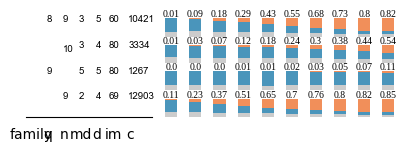

In [44]:
#fig = plt.figure(figsize=(7,2.0))
fig = plt.figure(figsize=(4,1.0))

ax = fig.subplot_mosaic(
    [
        #["label_tree", "q11n10k7w4"],
        #["label_tree", "q17n12md5w5"],
        ["label_tree", "q8n9k7w5"],
        ["label_tree", 'q9n10k8w4'],
        ["label_tree", "q9n10k6w5"],
        ["label_tree", "q9n9k8w4cb"],
        #["label_tree", "MERFISH_2015"],
    ],
    width_ratios=[1, 2],
)
ax["label_tree"].spines.top.set_visible(False)
ax["label_tree"].spines.right.set_visible(False)
ax["label_tree"].spines.left.set_visible(False)
ax["label_tree"].spines.bottom.set_visible(False)
ax["label_tree"].tick_params(bottom=False, left=False, labelleft=False)


ax["label_tree"].plot(["family", "q", "n", "md", "d", "im", "c", ""], [1,1,1,1,1,1,1,1], markersize=0,c="w")
ax["label_tree"].set_ylim(0,1)

tree_height_factor = 9.7 * 4/10

txt_top = 0.96
bar_width = 0.5


for i, grp in enumerate(reps_summed.groupby("ylabel")):
    print("i: ", i, "; g[0]: ", grp[0])
    code = grp[1].code.iloc[0]

    bottom = np.zeros(len(grp[1]))

    eff = grp[1]["Efficiency"]
    false = grp[1]["fp"]/grp[1]['nbarcodes']
    mis = 1 - eff - false
    fdr = grp[1]["False Discovery Rate"]

    if code in ax:
        p = ax[code].bar(grp[1]['Number of Barcodes'], false, bar_width, label="Proportion decoded incorrectly", bottom=1-false, color= "#f18f5a")
        ax[code].bar_label(p, np.round(fdr,2), label="False Discovery Rate", size=7, fontname="liberation serif")
                          
        p = ax[code].bar(grp[1]['Number of Barcodes'], eff, bar_width, label="Proportion decoded correctly", bottom=mis, color="#4a95bb")
        p = ax[code].bar(grp[1]['Number of Barcodes'], mis, bar_width, label="Proportion not decoded", bottom=bottom, color="#cccccc")
    
    
        
        ncws = grp[1].ncodewords.iloc[0]
        
        ax[code].spines.top.set_visible(False)
        ax[code].spines.right.set_visible(False)
        ax[code].spines.left.set_visible(False)
        ax[code].spines.bottom.set_visible(False)
        ax[code].tick_params(bottom=False, left=False, labelleft=False, labelbottom=False)

        #if code in code_n and code_n[code] != 6:
        if code_q[code] != 9 or code == 'q9n10k6w5':
            #if code_q[code] != 13:
            ax["label_tree"].text(0.9,txt_top-plot_order_dict[code]/tree_height_factor,code_q[code], size=7, fontname="arial")
            #if code_n[code] == 9:
            if not(code_n[code] == 10 and code_q[code] == 9):
                ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code], size=7, fontname="arial")
        if code == 'q9n9k8w4cb':
            ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code], size=7, fontname="arial")
        ax["label_tree"].text(2.9,txt_top-plot_order_dict[code]/tree_height_factor,code_mds[code], size=7, fontname="arial")
        ax["label_tree"].text(3.9,txt_top-plot_order_dict[code]/tree_height_factor,codebook_weights[code], size=7, fontname="arial")
        ax["label_tree"].text(4.7,txt_top-plot_order_dict[code]/tree_height_factor,nimgs_dict[code], size=7, fontname="arial")
        ax["label_tree"].text(5.9,txt_top-plot_order_dict[code]/tree_height_factor,ncws_dict[code], size=7, fontname="arial")

ax["label_tree"].spines.bottom.set_visible(True)

#lnd_artist = plt.legend(loc='upper right', bbox_to_anchor=(1.85,10))

print("code: ", code)

offset = 0.046
bracket_offset = 0.039 + 0.003



#ax["label_tree"].text(0.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_q["q9n10k8w4"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_n["q9n10k8w4"], size=7, fontname="arial")

#ax['MERFISH_2019'].set_xticks([1,2,3,4,5,6,7,8,9,10])
#ax['MERFISH_2019'].set_xlabel("Number of simulated barcodes")
#ax['MERFISH_2019'].tick_params(bottom=True, labelbottom=True)


brackets = []
pc_bracket = FancyArrowPatch((0.0,0.8),(0.2,0.8), arrowstyle={'arrowstyle':"-[,widthB=0.0, lengthB=0.2, angleB=0"}, mutation_scale=42)



plt.subplots_adjust(left=0.05,
                    bottom=0.0, 
                    right=1.0, 
                    top=1, 
                    wspace=0.01, 
                    hspace=0.4)

plt.savefig('figS2A_revision_RS_comp_codes.pdf', bbox_inches = 'tight') #, pad_inches = 5) # bbox_extra_artists=[lnd_artist])

i:  0 ; g[0]:  MERFISH_2015_ncws140_nimgs16
i:  1 ; g[0]:  MERFISH_2019_ncws12903_nimgs69
i:  2 ; g[0]:  NL_w5_md6_ncws12267_nimgs100
i:  3 ; g[0]:  RS_q11_n10_k7_w4_ncws2100_nimgs100
i:  4 ; g[0]:  RS_q13_n10_k6_w6_ncws20160_nimgs120
i:  5 ; g[0]:  RS_q13_n13_k9_w5_ncws15444_nimgs156
i:  6 ; g[0]:  RS_q8_n9_k6_w5_ncws3528_nimgs63
i:  7 ; g[0]:  full_q25_n4_k3_ncws15625_nimgs100
i:  8 ; g[0]:  q11n10k7w4_ncws271_nimgs100
i:  9 ; g[0]:  q17n12md5w5_ncws12672_nimgs192
i:  10 ; g[0]:  q25_n4_k3_ncws271_nimgs100
i:  11 ; g[0]:  q8n9k7w5_ncws10421_nimgs60
i:  12 ; g[0]:  q9n10k6w5_ncws1267_nimgs80
i:  13 ; g[0]:  q9n10k8w4_ncws3334_nimgs80
i:  14 ; g[0]:  q9n9k8w4cb_ncws12903_nimgs69
i:  15 ; g[0]:  seqFISHDNA_2020_ncws1267_nimgs80
i:  16 ; g[0]:  seqFISH_intron_2018_ncws10421_nimgs60
i:  17 ; g[0]:  seqFISH_q12_n5_k4_ncws20736_nimgs60
i:  18 ; g[0]:  seqFISH_q16_n5_k3_ncws4096_nimgs80
i:  19 ; g[0]:  seqFISHp2019_ncws8000_nimgs80
i:  20 ; g[0]:  seqFISHp2019_used_only_ncws3334_nimgs80
code

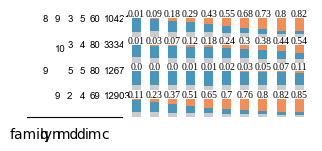

In [45]:
#fig = plt.figure(figsize=(7,2.0))
fig = plt.figure(figsize=(3,1.0))

ax = fig.subplot_mosaic(
    [
        #["label_tree", "q11n10k7w4"],
        #["label_tree", "q17n12md5w5"],
        ["label_tree", "q8n9k7w5"],
        ["label_tree", 'q9n10k8w4'],
        ["label_tree", "q9n10k6w5"],
        ["label_tree", "q9n9k8w4cb"],
        #["label_tree", "MERFISH_2015"],
    ],
    width_ratios=[1, 2],
)
ax["label_tree"].spines.top.set_visible(False)
ax["label_tree"].spines.right.set_visible(False)
ax["label_tree"].spines.left.set_visible(False)
ax["label_tree"].spines.bottom.set_visible(False)
ax["label_tree"].tick_params(bottom=False, left=False, labelleft=False)


ax["label_tree"].plot(["family", "q", "n", "md", "d", "im", "c", ""], [1,1,1,1,1,1,1,1], markersize=0,c="w")
ax["label_tree"].set_ylim(0,1)

tree_height_factor = 9.7 * 4/10

txt_top = 0.96
bar_width = 0.5


for i, grp in enumerate(reps_summed.groupby("ylabel")):
    print("i: ", i, "; g[0]: ", grp[0])
    code = grp[1].code.iloc[0]

    bottom = np.zeros(len(grp[1]))

    eff = grp[1]["Efficiency"]
    false = grp[1]["fp"]/grp[1]['nbarcodes']
    mis = 1 - eff - false
    fdr = grp[1]["False Discovery Rate"]

    if code in ax:
        p = ax[code].bar(grp[1]['Number of Barcodes'], false, bar_width, label="Proportion decoded incorrectly", bottom=1-false, color= "#f18f5a")
        ax[code].bar_label(p, np.round(fdr,2), label="False Discovery Rate", size=7, fontname="liberation serif")
                          
        p = ax[code].bar(grp[1]['Number of Barcodes'], eff, bar_width, label="Proportion decoded correctly", bottom=mis, color="#4a95bb")
        p = ax[code].bar(grp[1]['Number of Barcodes'], mis, bar_width, label="Proportion not decoded", bottom=bottom, color="#cccccc")
    
    
        
        ncws = grp[1].ncodewords.iloc[0]
        
        ax[code].spines.top.set_visible(False)
        ax[code].spines.right.set_visible(False)
        ax[code].spines.left.set_visible(False)
        ax[code].spines.bottom.set_visible(False)
        ax[code].tick_params(bottom=False, left=False, labelleft=False, labelbottom=False)

        #if code in code_n and code_n[code] != 6:
        if code_q[code] != 9 or code == 'q9n10k6w5':
            #if code_q[code] != 13:
            ax["label_tree"].text(0.9,txt_top-plot_order_dict[code]/tree_height_factor,code_q[code], size=7, fontname="arial")
            #if code_n[code] == 9:
            if not(code_n[code] == 10 and code_q[code] == 9):
                ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code], size=7, fontname="arial")
        if code == 'q9n9k8w4cb':
            ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code], size=7, fontname="arial")
        ax["label_tree"].text(2.9,txt_top-plot_order_dict[code]/tree_height_factor,code_mds[code], size=7, fontname="arial")
        ax["label_tree"].text(3.9,txt_top-plot_order_dict[code]/tree_height_factor,codebook_weights[code], size=7, fontname="arial")
        ax["label_tree"].text(4.7,txt_top-plot_order_dict[code]/tree_height_factor,nimgs_dict[code], size=7, fontname="arial")
        ax["label_tree"].text(5.9,txt_top-plot_order_dict[code]/tree_height_factor,ncws_dict[code], size=7, fontname="arial")

ax["label_tree"].spines.bottom.set_visible(True)

#lnd_artist = plt.legend(loc='upper right', bbox_to_anchor=(1.85,10))

print("code: ", code)

offset = 0.046
bracket_offset = 0.039 + 0.003



#ax["label_tree"].text(0.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_q["q9n10k8w4"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_n["q9n10k8w4"], size=7, fontname="arial")

#ax['MERFISH_2019'].set_xticks([1,2,3,4,5,6,7,8,9,10])
#ax['MERFISH_2019'].set_xlabel("Number of simulated barcodes")
#ax['MERFISH_2019'].tick_params(bottom=True, labelbottom=True)


brackets = []
pc_bracket = FancyArrowPatch((0.0,0.8),(0.2,0.8), arrowstyle={'arrowstyle':"-[,widthB=0.0, lengthB=0.2, angleB=0"}, mutation_scale=42)



plt.subplots_adjust(left=0.05,
                    bottom=0.0, 
                    right=1.0, 
                    top=1, 
                    wspace=0.01, 
                    hspace=0.4)

plt.savefig('figS2A_revision_RS_comp_codes.pdf', bbox_inches = 'tight') #, pad_inches = 5) # bbox_extra_artists=[lnd_artist])

i:  0 ; g[0]:  MERFISH_2015_ncws140_nimgs16
i:  1 ; g[0]:  MERFISH_2019_ncws12903_nimgs69
i:  2 ; g[0]:  NL_w5_md6_ncws12267_nimgs100
i:  3 ; g[0]:  RS_q11_n10_k7_w4_ncws2100_nimgs100
i:  4 ; g[0]:  RS_q13_n10_k6_w6_ncws20160_nimgs120
i:  5 ; g[0]:  RS_q13_n13_k9_w5_ncws15444_nimgs156
i:  6 ; g[0]:  RS_q8_n9_k6_w5_ncws3528_nimgs63
i:  7 ; g[0]:  full_q25_n4_k3_ncws15625_nimgs100
i:  8 ; g[0]:  q11n10k7w4_ncws271_nimgs100
i:  9 ; g[0]:  q17n12md5w5_ncws12672_nimgs192
i:  10 ; g[0]:  q25_n4_k3_ncws271_nimgs100
i:  11 ; g[0]:  q8n9k7w5_ncws10421_nimgs60
i:  12 ; g[0]:  q9n10k6w5_ncws1267_nimgs80
i:  13 ; g[0]:  q9n10k8w4_ncws3334_nimgs80
i:  14 ; g[0]:  q9n9k8w4cb_ncws12903_nimgs69
i:  15 ; g[0]:  seqFISHDNA_2020_ncws1267_nimgs80
i:  16 ; g[0]:  seqFISH_intron_2018_ncws10421_nimgs60
i:  17 ; g[0]:  seqFISH_q12_n5_k4_ncws20736_nimgs60
i:  18 ; g[0]:  seqFISH_q16_n5_k3_ncws4096_nimgs80
i:  19 ; g[0]:  seqFISHp2019_ncws8000_nimgs80
i:  20 ; g[0]:  seqFISHp2019_used_only_ncws3334_nimgs80
code

findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.
findfont: Font family 'arial narrow' not found.


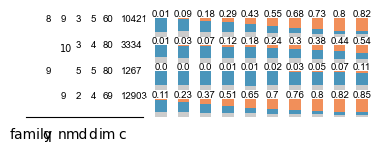

In [48]:
#fig = plt.figure(figsize=(7,2.0))
fig = plt.figure(figsize=(1.235*3,1.0))

ax = fig.subplot_mosaic(
    [
        #["label_tree", "q11n10k7w4"],
        #["label_tree", "q17n12md5w5"],
        ["label_tree", "q8n9k7w5"],
        ["label_tree", 'q9n10k8w4'],
        ["label_tree", "q9n10k6w5"],
        ["label_tree", "q9n9k8w4cb"],
        #["label_tree", "MERFISH_2015"],
    ],
    width_ratios=[1, 2],
)
ax["label_tree"].spines.top.set_visible(False)
ax["label_tree"].spines.right.set_visible(False)
ax["label_tree"].spines.left.set_visible(False)
ax["label_tree"].spines.bottom.set_visible(False)
ax["label_tree"].tick_params(bottom=False, left=False, labelleft=False)


ax["label_tree"].plot(["family", "q", "n", "md", "d", "im", "c", ""], [1,1,1,1,1,1,1,1], markersize=0,c="w")
ax["label_tree"].set_ylim(0,1)

tree_height_factor = 9.7 * 4/10

txt_top = 0.96
bar_width = 0.5


for i, grp in enumerate(reps_summed.groupby("ylabel")):
    print("i: ", i, "; g[0]: ", grp[0])
    code = grp[1].code.iloc[0]

    bottom = np.zeros(len(grp[1]))

    eff = grp[1]["Efficiency"]
    false = grp[1]["fp"]/grp[1]['nbarcodes']
    mis = 1 - eff - false
    fdr = grp[1]["False Discovery Rate"]

    if code in ax:
        p = ax[code].bar(grp[1]['Number of Barcodes'], false, bar_width, label="Proportion decoded incorrectly", bottom=1-false, color= "#f18f5a")
        ax[code].bar_label(p, np.round(fdr,2), label="False Discovery Rate", size=7, fontname="arial")
                          
        p = ax[code].bar(grp[1]['Number of Barcodes'], eff, bar_width, label="Proportion decoded correctly", bottom=mis, color="#4a95bb")
        p = ax[code].bar(grp[1]['Number of Barcodes'], mis, bar_width, label="Proportion not decoded", bottom=bottom, color="#cccccc")
    
    
        
        ncws = grp[1].ncodewords.iloc[0]
        
        ax[code].spines.top.set_visible(False)
        ax[code].spines.right.set_visible(False)
        ax[code].spines.left.set_visible(False)
        ax[code].spines.bottom.set_visible(False)
        ax[code].tick_params(bottom=False, left=False, labelleft=False, labelbottom=False)

        #if code in code_n and code_n[code] != 6:
        if code_q[code] != 9 or code == 'q9n10k6w5':
            #if code_q[code] != 13:
            ax["label_tree"].text(0.9,txt_top-plot_order_dict[code]/tree_height_factor,code_q[code], size=7, fontname="arial")
            #if code_n[code] == 9:
            if not(code_n[code] == 10 and code_q[code] == 9):
                ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code], size=7, fontname="arial")
        if code == 'q9n9k8w4cb':
            ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code], size=7, fontname="arial")
        ax["label_tree"].text(2.9,txt_top-plot_order_dict[code]/tree_height_factor,code_mds[code], size=7, fontname="arial")
        ax["label_tree"].text(3.9,txt_top-plot_order_dict[code]/tree_height_factor,codebook_weights[code], size=7, fontname="arial")
        ax["label_tree"].text(4.7,txt_top-plot_order_dict[code]/tree_height_factor,nimgs_dict[code], size=7, fontname="arial")
        ax["label_tree"].text(5.9,txt_top-plot_order_dict[code]/tree_height_factor,ncws_dict[code], size=7, fontname="arial")

ax["label_tree"].spines.bottom.set_visible(True)

#lnd_artist = plt.legend(loc='upper right', bbox_to_anchor=(1.85,10))

print("code: ", code)

offset = 0.046
bracket_offset = 0.039 + 0.003



#ax["label_tree"].text(0.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_q["q9n10k8w4"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["q9n10k8w4"]/tree_height_factor-offset,code_n["q9n10k8w4"], size=7, fontname="arial narrow")

#ax['MERFISH_2019'].set_xticks([1,2,3,4,5,6,7,8,9,10])
#ax['MERFISH_2019'].set_xlabel("Number of simulated barcodes")
#ax['MERFISH_2019'].tick_params(bottom=True, labelbottom=True)


brackets = []
pc_bracket = FancyArrowPatch((0.0,0.8),(0.2,0.8), arrowstyle={'arrowstyle':"-[,widthB=0.0, lengthB=0.2, angleB=0"}, mutation_scale=42)



plt.subplots_adjust(left=0.05,
                    bottom=0.0, 
                    right=1.0, 
                    top=1, 
                    wspace=0.01, 
                    hspace=0.4)

plt.savefig('figS2A_revision_RS_comp_codes.pdf', bbox_inches = 'tight') #, pad_inches = 5) # bbox_extra_artists=[lnd_artist])

In [ ]:
code_prop_perfect = reps_summed.set_index(["Number of Barcodes", "code"])["prop_perfect"].unstack("code")

In [ ]:
code_prop_perfect

code,MERFISH_2015,MERFISH_2019,NL_w5_md6,RS_q11_n10_k7_w4,RS_q13_n10_k6_w6,RS_q13_n13_k9_w5,RS_q8_n9_k6_w5,full_q25_n4_k3,q11n10k7w4,q17n12md5w5,...,q8n9k7w5,q9n10k6w5,q9n10k8w4,q9n9k8w4cb,seqFISHDNA_2020,seqFISH_intron_2018,seqFISH_q12_n5_k4,seqFISH_q16_n5_k3,seqFISHp2019,seqFISHp2019_used_only
Number of Barcodes,,,,,,,,,,,,,,,,,,,,,
1,0.996,0.952,0.998,0.996,0.998,1.000,0.996,0.972,1.000,1.000,...,0.996,1.000,0.996,0.922,1.000,0.992,0.984,0.996,0.978,0.988
2,0.846,0.824,0.996,0.994,0.996,0.994,0.984,0.880,1.000,1.000,...,0.890,0.998,0.958,0.712,0.996,0.878,0.756,0.972,0.874,0.948
3,0.588,0.588,0.966,0.960,0.996,0.996,0.928,0.714,0.994,0.994,...,0.712,0.998,0.878,0.444,0.976,0.670,0.452,0.894,0.734,0.868
4,0.346,0.360,0.894,0.934,0.984,0.968,0.838,0.458,0.988,0.990,...,0.520,0.978,0.756,0.230,0.948,0.370,0.204,0.820,0.486,0.748
5,0.154,0.202,0.824,0.886,0.940,0.944,0.686,0.314,0.976,0.974,...,0.316,0.972,0.594,0.074,0.892,0.222,0.062,0.668,0.324,0.610
6,0.072,0.074,0.696,0.808,0.874,0.894,0.514,0.168,0.972,0.956,...,0.198,0.934,0.436,0.036,0.806,0.052,0.020,0.516,0.142,0.368
7,0.030,0.028,0.564,0.696,0.808,0.874,0.350,0.082,0.966,0.918,...,0.044,0.864,0.336,0.008,0.748,0.030,0.004,0.358,0.058,0.302
8,0.006,0.006,0.398,0.548,0.688,0.808,0.252,0.032,0.934,0.882,...,0.030,0.802,0.198,0.002,0.636,0.008,0.000,0.276,0.038,0.164
9,0.000,0.004,0.280,0.468,0.590,0.690,0.088,0.008,0.904,0.806,...,0.006,0.730,0.144,0.000,0.558,0.004,0.000,0.160,0.010,0.082


In [ ]:
code2label = {
    'seqFISH_q12_n5_k4cb': "Q-ary Parity Check - q12 n5 k4: 20736 codewords",
    'seqFISH_intron_2018cb': 'Intron seqFISH 2018 Q-ary Parity Check - q12 n5 k4: 10421 codewords',
    'Hamming_q2_n16_k11_w4cb_MERFISH_2015cb': 'Hamming - q2 n16 k11 w4: 140 codewords',
    'MERFISH_2019cb': 'MERFISH 2019 Non-Linear - q2 n69 w4: 12903 codewords',
    'RS_q8_n9_k6_w5cb': 'Reed-Solomon q8 n9 k6 w5: 3528 codewords',
    'seqFISH_q16_n5_k3cb': 'Q-ary Parity Check - q16 n5 k3: 4096 codewords',
    'seqFISHp2019cb': 'Q-ary Parity Check - q20 n4 k3: 8000 codewords',
    'RS_q13_n10_k6_w6cb': 'Reed-Solomon - q13 n10 k6 w6: 20160',
    'unstructured_100bit_w5_md6cb': 'Non-Linear - q2 n100 w5 md6: 12267 codewords', 
    'seqFISH_n4k3q25_parity_checkcb': 'Q-ary Parity Check - q25 n4 k3: 15625 codewords',
    'seqFISHp2019_used_onlycb': 'RNA seqFISH+ Q-ary Parity Check - q20 n4 k3: 3334 codewords',
    'seqFISHDNA_2020cb': 'DNA seqFISH+ 2020 Q-ary Parity Check - q16 n5 k3: 1267 codewords',
    'RS_q13_n13_k9_w5cb': 'Reed-Solomon - q13 n13 k9 w5: 15444 codewords',
    'RS_q11_n10_k7_w4cb': 'Reed-Solomon - q11 n10 k7 w4: 2100 codewords',
    'seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1cb': 'Q-ary Parity Check - q25 n4 k3: 271 codewords',
    'q17n12md5w5cb': 'Reed-Solomon - q17 n12 md5 w5: 12672 codewords',
    'q11_n10_k7_w4cb_pool1cb': 'Reed-Solomon - q11 n10 k7 w4: 271 codewords'
}

dashed = ['seqFISH_q12_n5_k4',
'MERFISH_2015',
'MERFISH_2019',
'full_q25_n4_k3',
'seqFISHp2019',
'seqFISH_intron_2018',
'seqFISHp2019_used_only']

In [ ]:
code_prop_perfect.loc[5, :].sort_values()

code
seqFISH_q12_n5_k4         0.062
q9n9k8w4cb                0.074
MERFISH_2015              0.154
MERFISH_2019              0.202
seqFISH_intron_2018       0.222
full_q25_n4_k3            0.314
q8n9k7w5                  0.316
seqFISHp2019              0.324
q9n10k8w4                 0.594
seqFISHp2019_used_only    0.610
seqFISH_q16_n5_k3         0.668
RS_q8_n9_k6_w5            0.686
NL_w5_md6                 0.824
RS_q11_n10_k7_w4          0.886
seqFISHDNA_2020           0.892
RS_q13_n10_k6_w6          0.940
RS_q13_n13_k9_w5          0.944
q25_n4_k3                 0.966
q9n10k6w5                 0.972
q17n12md5w5               0.974
q11n10k7w4                0.976
Name: 5, dtype: float64

In [ ]:
sort_code_pp = code_prop_perfect.loc[5, :].sort_values(ascending=False)

In [ ]:
code2label = {
    'seqFISH_q12_n5_k4': "Q-ary Parity Check - q12 n5 k4: 20736 codewords",
    'seqFISH_intron_2018': 'Intron seqFISH 2018 Q-ary Parity Check - q12 n5 k4: 10421 codewords',
    'MERFISH_2015': 'Hamming - q2 n16 k11 w4: 140 codewords',
    'MERFISH_2019': 'MERFISH 2019 Non-Linear - q2 n69 w4: 12903 codewords',
    'RS_q8_n9_k6_w5': 'Reed-Solomon q8 n9 k6 w5: 3528 codewords',
    'seqFISH_q16_n5_k3': 'Q-ary Parity Check - q16 n5 k3: 4096 codewords',
    'seqFISHp2019': 'Q-ary Parity Check - q20 n4 k3: 8000 codewords',
    'RS_q13_n10_k6_w6': 'Reed-Solomon - q13 n10 k6 w6: 20160',
    'NL_w5_md6': 'Non-Linear - q2 n100 w5 md6: 12267 codewords', 
    'full_q25_n4_k3': 'Q-ary Parity Check - q25 n4 k3: 15625 codewords',
    'seqFISHp2019_used_only': 'RNA seqFISH+ Q-ary Parity Check - q20 n4 k3: 3334 codewords',
    'seqFISHDNA_2020': 'DNA seqFISH+ 2020 Q-ary Parity Check - q16 n5 k3: 1267 codewords',
    'RS_q13_n13_k9_w5': 'Reed-Solomon - q13 n13 k9 w5: 15444 codewords',
    'RS_q11_n10_k7_w4': 'Reed-Solomon - q11 n10 k7 w4: 2100 codewords',
    'q25_n4_k3': 'Q-ary Parity Check - q25 n4 k3: 271 codewords',
    'q17n12md5w5': 'Reed-Solomon - q17 n12 md5 w5: 12672 codewords',
    'q11n10k7w4': 'Reed-Solomon - q11 n10 k7 w4: 271 codewords'
}